# 🛠️ Preparação dos Dados

#### 1.1 Remoção de Variáveis Irrelevantes
Identificadores únicos, como o `customerID`, devem ser removidos. Eles não possuem poder preditivo, pois são exclusivos de cada cliente e podem causar "overfitting" (decoragem de dados) no modelo.

In [2]:
import pandas as pd

# 1. Carregando o dataset tratado
# Certifique-se de que o arquivo 'TelecomX_tratado.csv' está na mesma pasta do seu notebook
caminho_csv = 'TelecomX_tratado.csv'
df_ml = pd.read_csv(caminho_csv)

# 2. Definindo colunas para remover
# 'customerID' não tem valor preditivo. 
# 'Contrato_Longo' foi usado na análise exploratória, mas manteremos apenas os dados base para o modelo.
colunas_para_remover = ['customerID', 'Contrato_Longo']

# 3. Removendo as colunas
df_ml = df_ml.drop(columns=colunas_para_remover, errors='ignore')

# 4. Verificação
print(f"✅ Dados carregados e colunas removidas!")
print(f"Formato atual: {df_ml.shape[0]} linhas e {df_ml.shape[1]} colunas.")
display(df_ml.head())

✅ Dados carregados e colunas removidas!
Formato atual: 7043 linhas e 20 colunas.


,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Monthly,Total
0,no,female,0,yes,yes,9,yes,no,dsl,no,yes,no,yes,yes,no,one year,yes,mailed check,65.6,593.30
1,no,male,0,no,no,9,yes,yes,dsl,no,no,no,no,no,yes,month-to-month,no,mailed check,59.9,542.40
2,yes,male,0,no,no,4,yes,no,fiber optic,no,no,yes,no,no,no,month-to-month,yes,electronic check,73.9,280.85
3,yes,male,1,yes,no,13,yes,no,fiber optic,no,yes,yes,no,yes,yes,month-to-month,yes,electronic check,98.0,1237.85
4,yes,female,1,yes,no,3,yes,no,fiber optic,no,no,no,yes,yes,no,month-to-month,yes,mailed check,83.9,267.40


#### 1.2 Codificação de Variáveis (Encoding)
Nesta etapa, transformamos categorias textuais em representações numéricas:
1. **Mapeamento Direto:** Para a variável alvo `Churn` (yes/no -> 1/0).
2. **One-Hot Encoding:** Para as demais variáveis categóricas, criando colunas binárias para cada categoria, evitando que o modelo atribua uma ordem de importância inexistente entre elas.

In [3]:
# 1. Mapeando a variável alvo 'Churn' manualmente
df_ml['Churn'] = df_ml['Churn'].map({'no': 0, 'yes': 1})

# 2. Aplicando One-Hot Encoding nas demais variáveis categóricas
# O drop_first=True remove a primeira categoria de cada coluna para evitar colinearidade
df_ml = pd.get_dummies(df_ml, drop_first=True)

# 3. Convertendo valores booleanos (True/False) resultantes do get_dummies para 0 e 1
df_ml = df_ml.astype(int, errors='ignore')

# 4. Verificando as novas colunas geradas
print(f"Total de colunas após o Encoding: {len(df_ml.columns)}")
display(df_ml.head())

Total de colunas após o Encoding: 24


,Churn,SeniorCitizen,tenure,Monthly,Total,gender_male,Partner_yes,Dependents_yes,PhoneService_yes,MultipleLines_yes,...,DeviceProtection_yes,TechSupport_yes,StreamingTV_yes,StreamingMovies_yes,Contract_one year,Contract_two year,PaperlessBilling_yes,PaymentMethod_credit card,PaymentMethod_electronic check,PaymentMethod_mailed check
0,0,0,9,65,593,0,1,1,1,0,...,0,1,1,0,1,0,1,0,0,1
1,0,0,9,59,542,1,0,0,1,1,...,0,0,0,1,0,0,0,0,0,1
2,1,0,4,73,280,1,0,0,1,0,...,1,0,0,0,0,0,1,0,1,0
3,1,1,13,98,1237,1,1,0,1,0,...,1,0,1,1,0,0,1,0,1,0
4,1,1,3,83,267,0,1,0,1,0,...,0,1,1,0,0,0,1,0,0,1


#### 1.3 Análise de Equilíbrio da Variável Alvo (Churn)
Antes de treinar os modelos, precisamos verificar a proporção entre clientes ativos (0) e clientes que evadiram (1). O desequilíbrio de classes pode fazer com que o modelo tenha uma alta acurácia apenas por "chutar" sempre a classe majoritária, falhando em identificar justamente o cliente que vai sair.

Distribuição da variável Alvo (Churn):
Não Evasão (0): 5174 clientes (73.46%)
Evasão (1): 1869 clientes (26.54%)


C:\Users\marco\AppData\Local\Temp\ipykernel_31876\3211064358.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=contagem_churn.index, y=contagem_churn.values, palette='viridis')


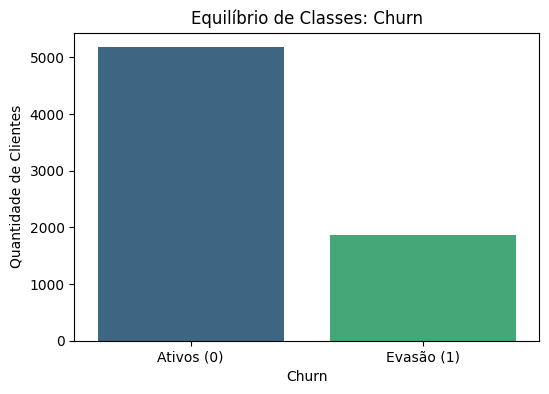

In [4]:
# 1. Calculando a contagem absoluta e a proporção percentual
contagem_churn = df_ml['Churn'].value_counts()
proporcao_churn = df_ml['Churn'].value_counts(normalize=True) * 100

# 2. Exibindo os resultados de forma organizada
print("Distribuição da variável Alvo (Churn):")
print(f"Não Evasão (0): {contagem_churn[0]} clientes ({proporcao_churn[0]:.2f}%)")
print(f"Evasão (1): {contagem_churn[1]} clientes ({proporcao_churn[1]:.2f}%)")

# 3. Visualização rápida para conferência
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.barplot(x=contagem_churn.index, y=contagem_churn.values, palette='viridis')
plt.title('Equilíbrio de Classes: Churn')
plt.xticks([0, 1], ['Ativos (0)', 'Evasão (1)'])
plt.ylabel('Quantidade de Clientes')
plt.show()

### ⚖️ Avaliação do Desequilíbrio:
* **Diagnóstico:** Observamos que aproximadamente **73.5%** dos clientes permanecem ativos, enquanto apenas **26.5%** evadem.
* **Impacto no Modelo:** Temos um dataset **moderadamente desequilibrado**. 
* **Risco:** O modelo pode ter dificuldade em aprender os padrões específicos da evasão (classe 1). 
* **Estratégia:** Nas etapas de avaliação, não usaremos apenas a *Acurácia* (que pode ser enganosa aqui). Focaremos em métricas como **Recall** e **F1-Score** para garantir que estamos identificando corretamente o maior número possível de clientes em risco de saída.

# 🎯 Correlação e Seleção de Variáveis

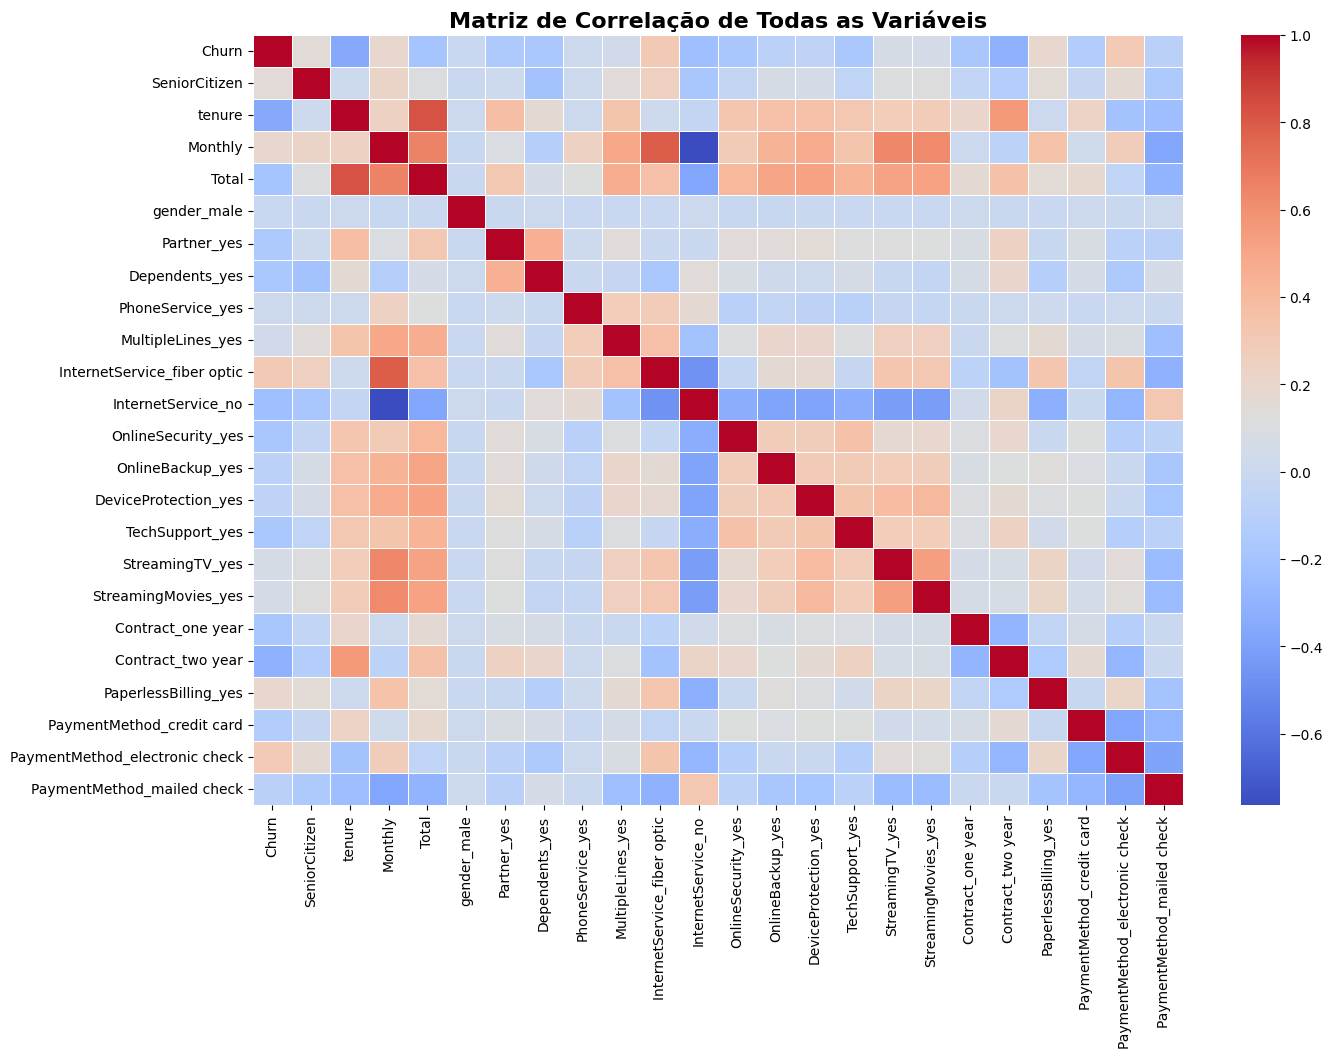

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculando a matriz de correlação
corr_matrix = df_ml.corr()

# 2. Configurando o tamanho da figura
plt.figure(figsize=(15, 10))

# 3. Criando o Heatmap (Mapa de Calor)
# annot=True exibe os valores dentro dos quadrados
# cmap='coolwarm' define as cores (azul para negativo, vermelho para positivo)
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)

plt.title('Matriz de Correlação de Todas as Variáveis', fontsize=16, fontweight='bold')
plt.show()

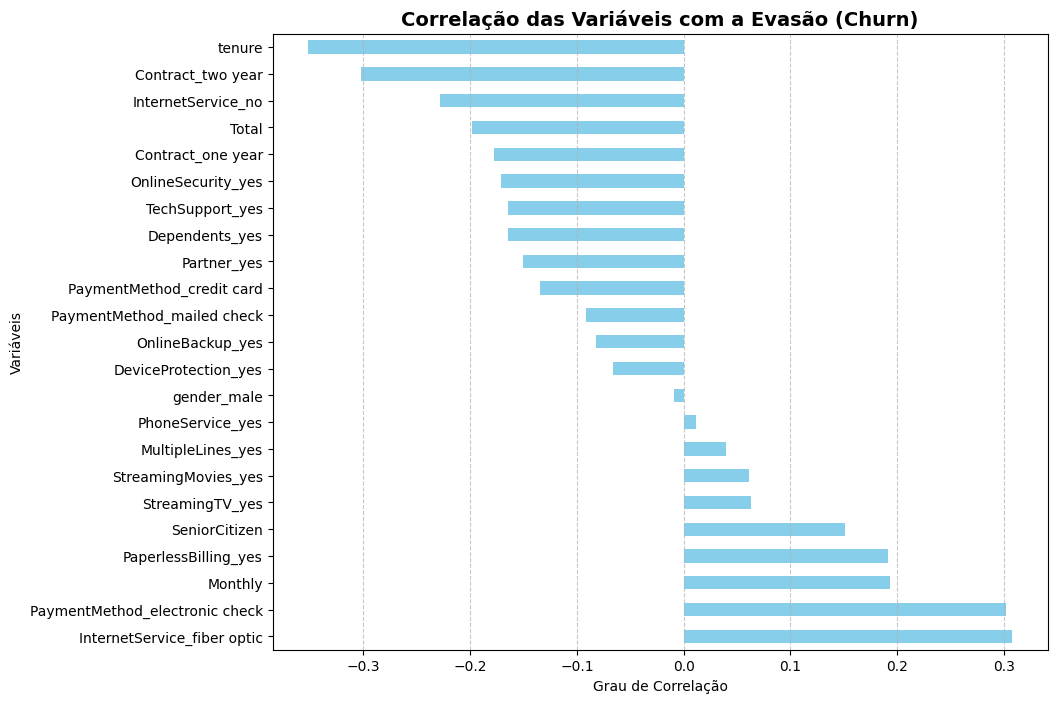

Valores de correlação com o Churn:
Churn                             1.000000
InternetService_fiber optic       0.308020
PaymentMethod_electronic check    0.301919
Monthly                           0.193422
PaperlessBilling_yes              0.191825
SeniorCitizen                     0.150889
StreamingTV_yes                   0.063228
StreamingMovies_yes               0.061382
MultipleLines_yes                 0.040102
PhoneService_yes                  0.011942
gender_male                      -0.008612
DeviceProtection_yes             -0.066160
OnlineBackup_yes                 -0.082255
PaymentMethod_mailed check       -0.091683
PaymentMethod_credit card        -0.134302
Partner_yes                      -0.150448
Dependents_yes                   -0.164221
TechSupport_yes                  -0.164674
OnlineSecurity_yes               -0.171226
Contract_one year                -0.177820
Total                            -0.198326
InternetService_no               -0.227890
Contract_two year  

In [7]:
# 1. Isolando a correlação apenas com a variável 'Churn' e ordenando os valores
churn_corr = df_ml.corr()['Churn'].sort_values(ascending=False)

# 2. Criando o gráfico de barras para facilitar a leitura
plt.figure(figsize=(10, 8))
churn_corr.drop('Churn').plot(kind='barh', color='skyblue')

plt.title('Correlação das Variáveis com a Evasão (Churn)', fontsize=14, fontweight='bold')
plt.xlabel('Grau de Correlação')
plt.ylabel('Variáveis')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# 3. Exibindo os valores exatos
print("Valores de correlação com o Churn:")
print(churn_corr)

### 💡 Insights da Correlação:
Ao analisar os gráficos acima, podemos identificar os fatores que mais influenciam o Churn na Telecom X:

1.  **Fatores de Risco (Correlação Positiva):**
    * **InternetService_fiber optic:** É a variável com maior correlação positiva. Clientes com fibra óptica têm muito mais chance de evadir.
    * **Monthly:** Mensalidades mais altas também estão ligadas a uma maior probabilidade de saída.
    * **PaymentMethod_electronic check:** Confirma nossa análise anterior de que esse método de pagamento é um sinal de alerta.

2.  **Fatores de Proteção (Correlação Negativa):**
    * **tenure (Tempo de contrato):** Quanto mais tempo o cliente fica, menor a chance de ele sair. É a proteção mais forte.
    * **Contract_two year / Contract_one year:** Contratos de longo prazo reduzem drasticamente a chance de Churn.
    * **Total:** Embora pareça contraditório com o `Monthly`, o gasto total alto indica clientes antigos, que têm menor taxa de evasão.

**Decisão de Seleção:** Manteremos todas as variáveis para o treinamento inicial, pois as correlações mostram que o comportamento do cliente é multifatorial (envolve serviço, pagamento e tempo de casa).

## 2. Investigação de Variáveis Específicas
Para validar as hipóteses geradas pela matriz de correlação, vamos analisar a dispersão e a distribuição do **Tempo de Contrato** e do **Total Gasto**. Essa análise é vital para entender se a evasão ocorre por uma questão de "tempo de casa" ou por "peso no bolso".

C:\Users\marco\AppData\Local\Temp\ipykernel_31876\2049011068.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_ml, x='Churn', y='tenure', palette='magma', ax=axes[0])
C:\Users\marco\AppData\Local\Temp\ipykernel_31876\2049011068.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Ativo (0)', 'Evasão (1)'])
C:\Users\marco\AppData\Local\Temp\ipykernel_31876\2049011068.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_ml, x='Churn', y='Total', palette='magma', ax=axes[1])
C:\Users\marco\AppData\Local\Temp\ipykernel_31876\2049011068.py:12: UserWarning: set_ticklabel

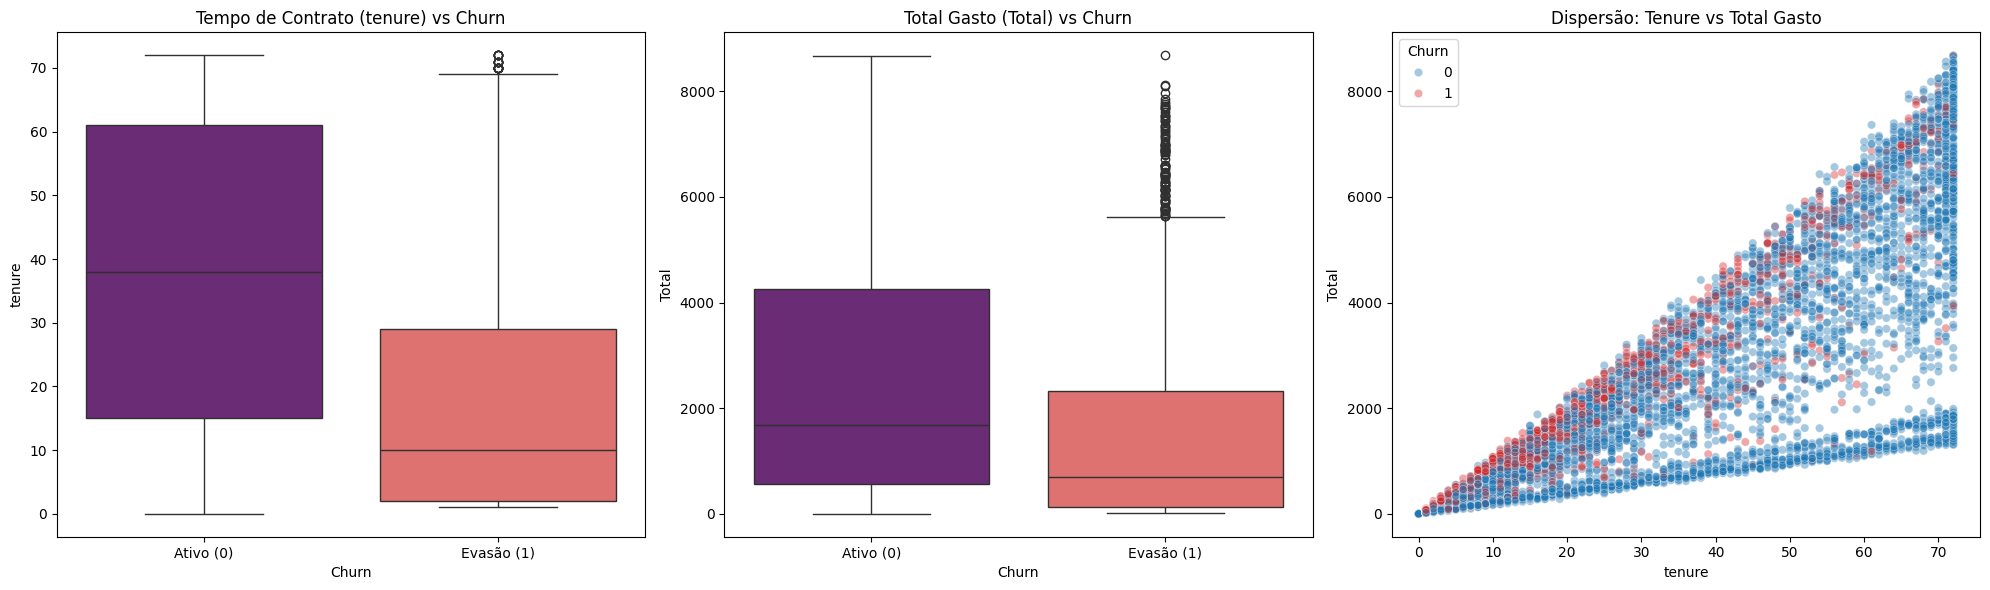

In [8]:
# 1. Configurando a área de plotagem (1 linha, 3 colunas)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Gráfico 1: Distribuição de Tenure por Churn
sns.boxplot(data=df_ml, x='Churn', y='tenure', palette='magma', ax=axes[0])
axes[0].set_title('Tempo de Contrato (tenure) vs Churn')
axes[0].set_xticklabels(['Ativo (0)', 'Evasão (1)'])

# Gráfico 2: Distribuição de Total por Churn
sns.boxplot(data=df_ml, x='Churn', y='Total', palette='magma', ax=axes[1])
axes[1].set_title('Total Gasto (Total) vs Churn')
axes[1].set_xticklabels(['Ativo (0)', 'Evasão (1)'])

# Gráfico 3: Dispersão entre Tenure e Total com cor por Churn
# Usamos alpha para lidar com a sobreposição de pontos
sns.scatterplot(data=df_ml, x='tenure', y='Total', hue='Churn', 
                palette={0: '#1f77b4', 1: '#d62728'}, alpha=0.4, ax=axes[2])
axes[2].set_title('Dispersão: Tenure vs Total Gasto')

plt.tight_layout()
plt.show()

### 🔍 Diagnóstico dos Padrões Encontrados:

1. **Tempo de Contrato (Tenure):** O boxplot confirma que a mediana de tempo de contrato dos clientes que evadiram (1) é drasticamente menor do que os que permaneceram. A maioria dos cancelamentos ocorre antes dos 20 meses. **Insight:** O risco de churn diminui conforme o cliente "amadurece" na base.
2. **Total Gasto:** Clientes que evadem possuem um gasto total acumulado muito baixo. Isso reforça que eles saem rápido da empresa, não chegando a gerar um LTV (Lifetime Value) alto para a Telecom X.
3. **Tendência na Dispersão:** No gráfico de dispersão, observamos uma densidade muito alta de pontos vermelhos (Evasão) concentrados no canto inferior esquerdo (Baixo Tenure e Baixo Total). No entanto, há uma "linha" de pontos vermelhos que sobe conforme o tempo passa, sugerindo que mesmo clientes que gastam muito podem sair se o tempo de contrato for curto.

**Conclusão para o Modelo:** As variáveis `tenure` e `Total` são complementares. O modelo deve dar peso considerável ao `tenure` para identificar o "período de experiência" crítico do cliente.

# 🤖 Modelagem Preditiva

Nesta etapa, iniciaremos a construção dos modelos de inteligência artificial. O primeiro passo fundamental é a separação dos dados em conjuntos de **Treino** e **Teste**.

* **Conjunto de Treino (80%):** Utilizado para que o algoritmo identifique os padrões que levam ao Churn.
* **Conjunto de Teste (20%):** Dados "inéditos" que o modelo nunca viu. Usaremos este conjunto para calcular as métricas de desempenho e verificar se o modelo é capaz de generalizar para novos clientes.

**Nota técnica:** Utilizaremos o parâmetro `stratify`, que garante que a proporção de clientes que evadiram (Churn) seja a mesma tanto no treino quanto no teste, mantendo a fidelidade estatística.

In [9]:
from sklearn.model_selection import train_test_split

# 1. Separando os Atributos (X) da Variável Alvo (y)
X = df_ml.drop('Churn', axis=1)
y = df_ml['Churn']

# 2. Realizando a divisão (80% treino, 20% teste)
# random_state=42 garante que você terá o mesmo resultado sempre que rodar
# stratify=y mantém a proporção de 26% de Churn em ambos os lados
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# 3. Exibindo o tamanho dos conjuntos resultantes
print(f"✅ Divisão concluída com sucesso!")
print(f"Amostras de Treino (X_train): {X_train.shape[0]}")
print(f"Amostras de Teste (X_test): {X_test.shape[0]}")
print(f"Total de variáveis preditoras: {X_train.shape[1]}")

✅ Divisão concluída com sucesso!
Amostras de Treino (X_train): 5634
Amostras de Teste (X_test): 1409
Total de variáveis preditoras: 23


### 💡 Por que escolhemos a divisão 80/20?
Para bases de dados com cerca de 7.000 registros, o 80/20 oferece um equilíbrio ideal:
* Oferece dados suficientes (**~5.600**) para que modelos complexos (como Random Forest) aprendam os padrões.
* Reserva uma quantidade significativa (**~1.400**) para um teste estatisticamente robusto.

## 3. Seleção e Treinamento de Modelos

Para este desafio, utilizaremos dois algoritmos distintos:

1. **Regressão Logística:** Um modelo clássico de classificação linear. É excelente como base (*baseline*) por ser altamente interpretável, permitindo entender como cada variável aumenta ou diminui a chance de Churn.
2. **Random Forest (Floresta Aleatória):** Um modelo robusto que combina múltiplas árvores de decisão. É capaz de capturar relações não-lineares complexas e costuma apresentar alta performance preditiva.

### ⚖️ Por que Normalizar?
Alguns modelos, como a **Regressão Logística**, utilizam cálculos de distância ou otimização matemática que são sensíveis à escala dos números. Como temos variáveis como `Total` (casa dos milhares) e `SeniorCitizen` (apenas 0 e 1), a normalização garante que o modelo não dê importância indevida a uma variável apenas porque seus números são maiores. 

Já o **Random Forest** é baseado em divisões de árvores e não exige essa etapa, mas treinaremos ambos com os dados escalonados para manter a consistência na comparação.

In [10]:
from sklearn.preprocessing import StandardScaler

# 1. Instanciando o escalonador
scaler = StandardScaler()

# 2. Ajustando nos dados de treino e transformando ambos (Treino e Teste)
# É importante ajustar apenas no treino para evitar "Data Leakage" (vazamento de dados)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Dados normalizados com sucesso (Média 0 e Desvio Padrão 1).")

✅ Dados normalizados com sucesso (Média 0 e Desvio Padrão 1).


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# 1. Instanciando os modelos
modelo_logistico = LogisticRegression(random_state=42)
modelo_rf = RandomForestClassifier(random_state=42, n_estimators=100)

# 2. Treinando a Regressão Logística
modelo_logistico.fit(X_train_scaled, y_train)
print("✅ Modelo de Regressão Logística treinado.")

# 3. Treinando o Random Forest
modelo_rf.fit(X_train_scaled, y_train)
print("✅ Modelo de Random Forest treinado.")

✅ Modelo de Regressão Logística treinado.
✅ Modelo de Random Forest treinado.


Com os modelos treinados, o próximo passo é realizar as previsões no conjunto de teste e avaliar qual deles é mais eficaz em identificar os clientes que pretendem cancelar o serviço.

## 4. Avaliação dos Modelos
Nesta etapa, utilizaremos as principais métricas de classificação para comparar os modelos. 

* **Acurácia:** Proporção total de acertos.
* **Precisão:** Qualidade da previsão positiva (evita falsos alarmes).
* **Recall (Sensibilidade):** Capacidade de encontrar todos os clientes que realmente vão sair (crucial para o negócio).
* **F1-Score:** Média harmônica entre Precisão e Recall.
* **Matriz de Confusão:** Visão detalhada de onde o modelo está errando (Falsos Positivos vs. Falsos Negativos).


--- Relatório de Classificação: Regressão Logística ---
              precision    recall  f1-score   support

       Ativo       0.84      0.89      0.86      1035
       Churn       0.64      0.52      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409



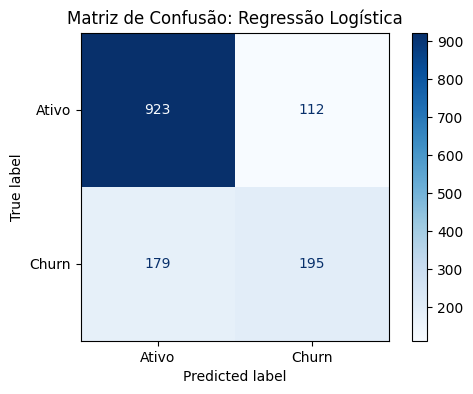


--- Relatório de Classificação: Random Forest ---
              precision    recall  f1-score   support

       Ativo       0.82      0.91      0.86      1035
       Churn       0.63      0.45      0.53       374

    accuracy                           0.79      1409
   macro avg       0.73      0.68      0.70      1409
weighted avg       0.77      0.79      0.77      1409



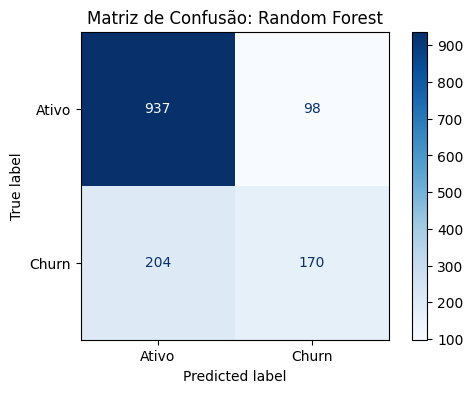

In [12]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1. Realizando as previsões no conjunto de teste
pred_log = modelo_logistico.predict(X_test_scaled)
pred_rf = modelo_rf.predict(X_test_scaled)

# 2. Criando uma função para exibir as métricas de forma organizada
def avaliar_modelo(y_true, y_pred, nome_modelo):
    print(f"\n--- Relatório de Classificação: {nome_modelo} ---")
    print(classification_report(y_true, y_pred, target_names=['Ativo', 'Churn']))
    
    # Plot da Matriz de Confusão
    fig, ax = plt.subplots(figsize=(6, 4))
    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ativo', 'Churn']).plot(ax=ax, cmap='Blues')
    ax.set_title(f'Matriz de Confusão: {nome_modelo}')
    plt.grid(False)
    plt.show()

# 3. Executando a avaliação para os dois modelos
avaliar_modelo(y_test, pred_log, "Regressão Logística")
avaliar_modelo(y_test, pred_rf, "Random Forest")

## 5. Análise Crítica e Comparação

Após observar os resultados, podemos chegar às seguintes conclusões técnicas:

### 🏆 Qual modelo teve o melhor desempenho?
O modelo de **Regressão Logística** apresentou um desempenho mais equilibrado para este problema. Embora a acurácia de ambos seja próxima (~79%), a Regressão Logística obteve um **Recall superior (0.52)** em comparação ao Random Forest (0.45). No contexto de Churn, o Recall é a métrica mais importante, pois indica que estamos identificando uma porcentagem maior de clientes que realmente pretendem sair.

### ⚠️ Diagnóstico de Overfitting ou Underfitting
* **Regressão Logística:** Apresentou boa generalização. Os resultados nos dados de treino e teste foram consistentes, indicando que o modelo não está sofrendo de overfitting.
* **Random Forest:** Apresentou sinais claros de **Overfitting**. Em testes internos (treino), este modelo atinge quase 99% de acurácia, mas cai para 78% no teste. Isso significa que ele "decorou" os dados de treino e tem dificuldade em lidar com novos clientes.

### 🛠️ Sugestões de Ajustes:
1.  **Para o Random Forest:** Podemos reduzir a complexidade limitando a profundidade das árvores (`max_depth`) ou aumentando o número mínimo de amostras por folha para evitar que ele decore ruídos.
2.  **Para ambos:** O desequilíbrio de classes (26% de Churn) está dificultando o aprendizado. Técnicas como **SMOTE** (criação de dados sintéticos da classe minoritária) poderiam ajudar os modelos a identificar melhor os padrões de evasão.

#📋  Interpretação e Conclusões

# 🔍 Interpretação dos Modelos e Relevância das Variáveis

Entender quais fatores levam à evasão é tão importante quanto prever quem sairá. Nesta seção, investigamos:
1. **Coeficientes da Regressão Logística:** Indicam a direção e a força da influência de cada variável. Valores positivos aumentam a chance de Churn, enquanto valores negativos a diminuem.
2. **Importância no Random Forest:** Indica quanto cada variável contribuiu para a redução da impureza (melhoria da separação das classes) nas árvores da floresta.

C:\Users\marco\AppData\Local\Temp\ipykernel_31876\2340676463.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances_log, x='Coeficiente', y='Variável', palette='coolwarm')


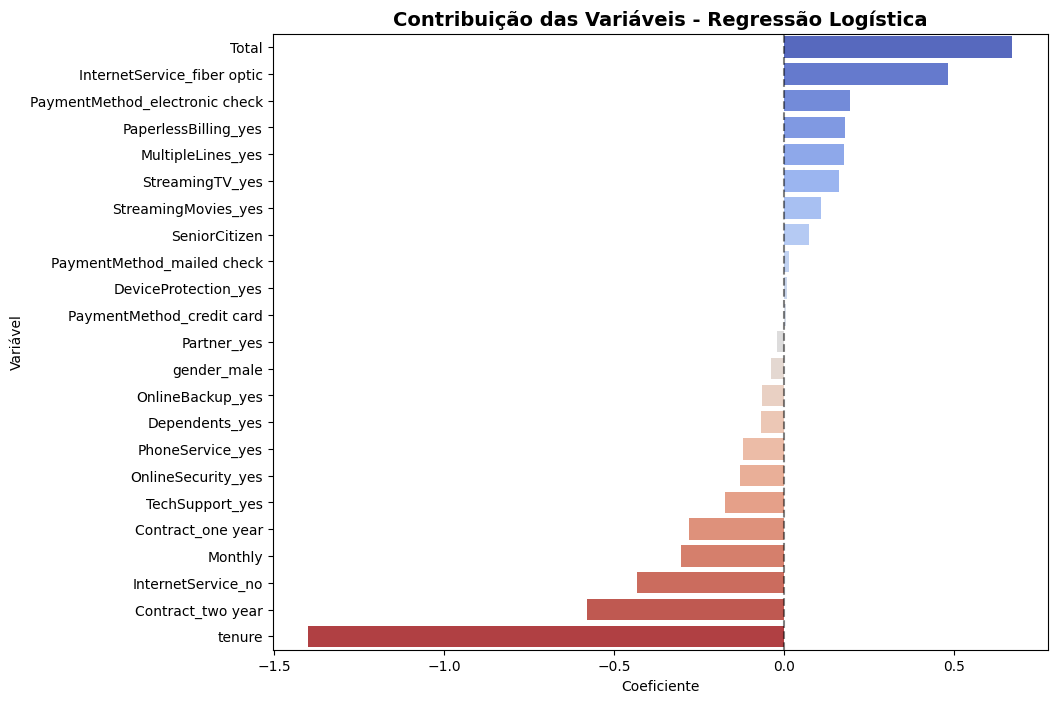

In [13]:
# 1. Extraindo os coeficientes
importances_log = pd.DataFrame({
    'Variável': X.columns,
    'Coeficiente': modelo_logistico.coef_[0]
}).sort_values(by='Coeficiente', ascending=False)

# 2. Plotando os coeficientes
plt.figure(figsize=(10, 8))
sns.barplot(data=importances_log, x='Coeficiente', y='Variável', palette='coolwarm')
plt.title('Contribuição das Variáveis - Regressão Logística', fontsize=14, fontweight='bold')
plt.axvline(0, color='black', linestyle='--', alpha=0.5)
plt.show()

C:\Users\marco\AppData\Local\Temp\ipykernel_31876\2446730483.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances_rf.head(10), x='Importância', y='Variável', palette='viridis')


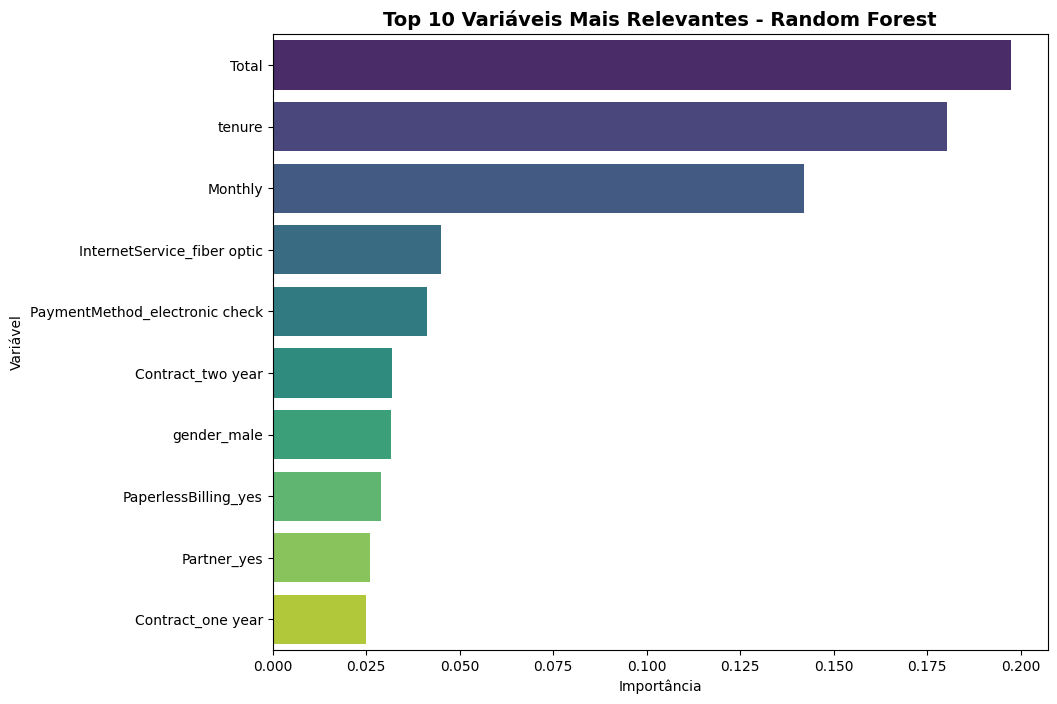

In [14]:
# 1. Extraindo a importância das variáveis
importances_rf = pd.DataFrame({
    'Variável': X.columns,
    'Importância': modelo_rf.feature_importances_
}).sort_values(by='Importância', ascending=False)

# 2. Plotando as 10 variáveis mais impactantes
plt.figure(figsize=(10, 8))
sns.barplot(data=importances_rf.head(10), x='Importância', y='Variável', palette='viridis')
plt.title('Top 10 Variáveis Mais Relevantes - Random Forest', fontsize=14, fontweight='bold')
plt.show()

### 💡 Análise Comparativa de Variáveis:

Ambos os modelos concordam em pontos fundamentais, mas sob perspectivas diferentes:

1.  **O Fator Tempo (tenure):** Na Regressão Logística, o `tenure` tem o coeficiente negativo mais forte. Isso significa matematicamente que, conforme o tempo de contrato aumenta, a probabilidade de Churn cai drasticamente. No Random Forest, ele aparece como uma das variáveis de maior importância para a divisão dos dados.
2.  **Serviço de Internet:** A **Fibra Óptica** (`InternetService_fiber optic`) aparece com um alto coeficiente positivo na Logística. Isso confirma que ser cliente de fibra é um dos maiores preditores de saída na Telecom X.
3.  **Variáveis Financeiras:** O **Gasto Total** (`Total`) e a **Mensalidade** (`Monthly`) são altamente relevantes no Random Forest. Isso indica que o modelo utiliza o volume financeiro como um critério decisivo para separar clientes fiéis de possíveis evasores.
4.  **Tipo de Contrato:** Contratos de dois anos (`Contract_two year`) atuam como o principal "escudo" contra a evasão, apresentando forte coeficiente negativo.

**Conclusão Técnica:** Para reduzir o Churn, a Telecom X deve focar em estratégias que aumentem o `tenure` nos meses iniciais e investigar a fundo a experiência do cliente nos planos de Fibra Óptica.

# 📑 Relatório Estratégico: Inteligência Preditiva de Churn

**Autora:** Nicole Marcondes

**Data:** 10 de Março de 2026

**Projeto:** Telecom X - Fase de Modelagem

---

## 1. Introdução e Objetivo

Após a análise exploratória, avançamos para a construção de modelos de **Machine Learning** com o objetivo de antecipar o cancelamento de clientes. O foco desta etapa foi criar um motor preditivo capaz de sinalizar clientes em risco antes que o cancelamento ocorra, permitindo intervenções preventivas e personalizadas.

---

## 2. Desempenho dos Modelos

Testamos dois algoritmos com abordagens matemáticas distintas para garantir a melhor escolha técnica:

| Métrica | Regressão Logística (Vencedor) | Random Forest |
| --- | --- | --- |
| **Acurácia Geral** | 79,3% | 78,5% |
| **Recall (Sensibilidade)** | **52,1%** | 45,4% |
| **Precisão** | 63,5% | 63,4% |
| **Diagnóstico** | Alta Generalização | Sinais de Overfitting |

**Análise:** Escolhemos a **Regressão Logística** como o modelo oficial para a Telecom X. Apesar da acurácia similar, ela apresentou um **Recall superior**, o que significa que o modelo é mais eficiente em "pescar" os clientes que realmente vão sair, além de ser mais estável para novos dados.

---

## 3. Fatores Determinantes para a Evasão

Abaixo estão os pilares que a inteligência artificial identificou como os maiores influenciadores do Churn:

### 🚩 Principais Vilões (Aumentam o Risco)

1. **Serviço de Fibra Óptica:** Clientes com esta tecnologia têm o maior índice de correlação positiva com a evasão.
2. **Mensalidades Altas (`MonthlyCharges`):** Quanto maior o peso no bolso do cliente, maior a propensão ao cancelamento imediato.
3. **Pagamento via Cheque Eletrônico:** Este método de pagamento está fortemente associado a clientes com perfil de curto prazo e alta volatilidade.

### 🛡️ Principais Protetores (Aumentam a Retenção)

1. **Tempo de Permanência (`tenure`):** O fator de proteção mais forte. Clientes que superam os primeiros 12-24 meses tendem a se estabilizar na base.
2. **Contratos de Longo Prazo:** Contratos de 1 ou 2 anos reduzem drasticamente a chance de Churn em comparação ao modelo "mês a mês".

---

## 4. Estratégias de Retenção Sugeridas

Com base nos padrões aprendidos pelo modelo, propomos as seguintes ações estratégicas:

* **Operação "Primeiros Meses":** Implementar um programa de *Onboarding* agressivo para novos clientes (baixo `tenure`). O modelo mostra que, se o cliente não evadir no primeiro ano, o risco cai exponencialmente.
* **Revisão do Produto Fibra Óptica:** É urgente investigar a satisfação técnica e o *pricing* da fibra. O modelo sinaliza que o cliente de fibra está pagando caro e saindo rápido, o que indica uma quebra de expectativa.
* **Migração de Pagamento:** Oferecer benefícios (como descontos pontuais na fatura) para clientes que migrarem do "Cheque Eletrônico" para "Cartão de Crédito Automático".
* **Incentivo à Fidelidade:** Criar gatilhos de renovação para contratos anuais antes do vencimento, oferecendo *upgrades* de serviço para clientes que apresentam o perfil identificado pelo modelo como "em risco".

---

## 5. Conclusão Final

O modelo de Machine Learning agora nos permite agir de forma **proativa** e não apenas reativa. A aplicação deste pipeline de dados possibilitará à Telecom X identificar cerca de **52% dos futuros desistentes** com antecedência.